In [1]:
# Cell 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
# Cell 2 — Load Dataset

file_path = r"C:\Users\bts\OneDrive\Desktop\SaiKet Systems\dataset\Telco_Customer_Churn_Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


In [3]:
# Cell 3 — Display First Five Rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Cell 4 — Dataset Information

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Number of rows: 7043
Number of columns: 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
# Cell 5 — Check Missing Values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values: 0


In [6]:
# Cell 6 — Check Duplicate Records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [7]:
# Cell 7 — Descriptive Statistics

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Cell 8 — Check Unique Values

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:10])


customerID:
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU']
Length: 10, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen:
[0 1]

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure:
[ 1 34  2 45  8 22 10 28 62 13]

PhoneService:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Tec

In [9]:
# Cell 9 — Data Cleaning: Convert TotalCharges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Invalid TotalCharges values:", df["TotalCharges"].isnull().sum())

TotalCharges data type: float64
Invalid TotalCharges values: 11


In [10]:
# Cell 10 — Handle Missing and Invalid Values

print("Dataset shape before cleaning:", df.shape)

df = df.dropna().copy()

print("Dataset shape after cleaning:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())

Dataset shape before cleaning: (7043, 21)
Dataset shape after cleaning: (7032, 21)
Remaining missing values: 0


In [11]:
# Cell 11 — Convert Churn into Binary Target

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [12]:
# Cell 12 — Churn Class Distribution

churn_distribution = df["Churn"].value_counts()

print("Churn Distribution:")
print(churn_distribution)

print("\nChurn Percentage:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn Distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn Percentage:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


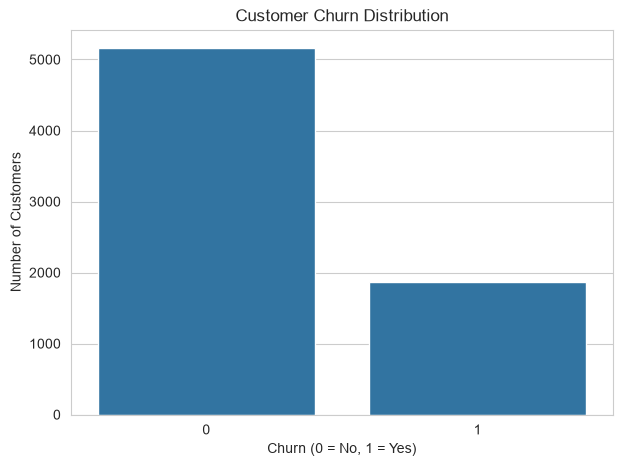

In [13]:
# Cell 13 — Churn Distribution Visualization

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
# Cell 14 — Separate Features and Target

# customerID is an identifier and should not be used as a model feature.

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (7032, 19)
Target shape: (7032,)


In [15]:
# Cell 15 — Identify Numerical and Categorical Features

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
# Cell 16 — Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 5625
Testing samples: 1407

Training churn distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


In [17]:
# Cell 17 — Create Preprocessing Pipeline

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [18]:
# Cell 18 — Logistic Regression Model

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [19]:
# Cell 19 — Evaluate Logistic Regression

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-Score :", round(logistic_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

Logistic Regression Results
--------------------------------
Accuracy : 0.8053
Precision: 0.6515
Recall   : 0.5749
F1-Score : 0.6108

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [20]:
# Cell 20 — Decision Tree Model

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


In [21]:
# Cell 21 — Evaluate Decision Tree

tree_accuracy = accuracy_score(y_test, decision_tree_predictions)
tree_precision = precision_score(y_test, decision_tree_predictions)
tree_recall = recall_score(y_test, decision_tree_predictions)
tree_f1 = f1_score(y_test, decision_tree_predictions)

print("Decision Tree Results")
print("--------------------------------")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1-Score :", round(tree_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, decision_tree_predictions))

Decision Tree Results
--------------------------------
Accuracy : 0.7164
Precision: 0.4661
Recall   : 0.4599
F1-Score : 0.463

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1033
           1       0.47      0.46      0.46       374

    accuracy                           0.72      1407
   macro avg       0.64      0.63      0.64      1407
weighted avg       0.72      0.72      0.72      1407



In [22]:
# Cell 22 — Random Forest Model

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [23]:
# Cell 23 — Evaluate Random Forest

forest_accuracy = accuracy_score(y_test, random_forest_predictions)
forest_precision = precision_score(y_test, random_forest_predictions)
forest_recall = recall_score(y_test, random_forest_predictions)
forest_f1 = f1_score(y_test, random_forest_predictions)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(forest_accuracy, 4))
print("Precision:", round(forest_precision, 4))
print("Recall   :", round(forest_recall, 4))
print("F1-Score :", round(forest_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, random_forest_predictions))

Random Forest Results
--------------------------------
Accuracy : 0.7868
Precision: 0.6225
Recall   : 0.5027
F1-Score : 0.5562

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [24]:
# Cell 24 — Baseline Model Comparison

baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall
    ],
    "F1-Score": [
        logistic_f1,
        tree_f1,
        forest_f1
    ]
})

baseline_results = baseline_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

baseline_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8053,0.6515,0.5749,0.6108
1,Random Forest,0.7868,0.6225,0.5027,0.5562
2,Decision Tree,0.7164,0.4661,0.4599,0.4630


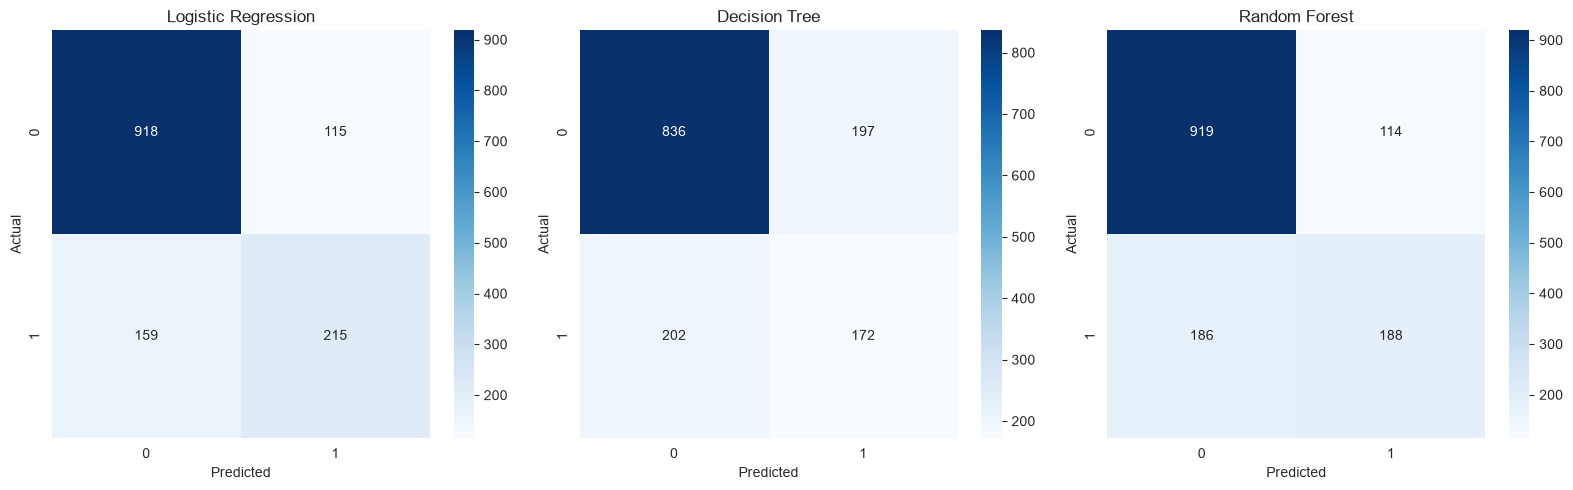

In [25]:
# Cell 25 — Confusion Matrices for Baseline Models

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

for ax, (model_name, predictions) in zip(
    axes,
    models_predictions.items()
):
    cm = confusion_matrix(y_test, predictions)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

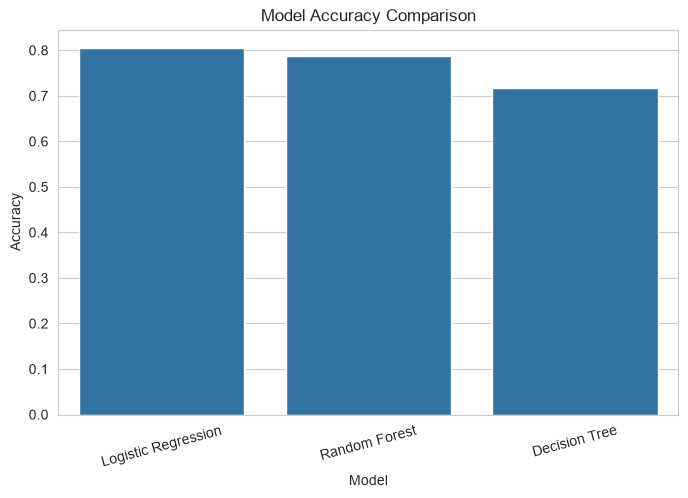

In [26]:
# Cell 26 — Accuracy Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

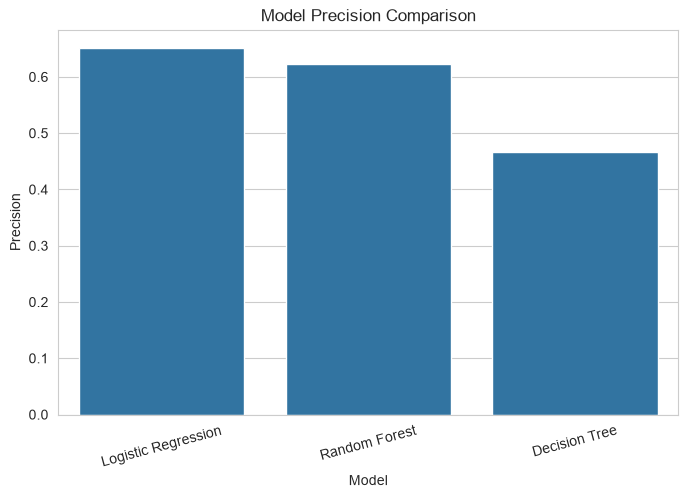

In [27]:
# Cell 27 — Precision Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="Precision"
)

plt.title("Model Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.xticks(rotation=15)

plt.show()

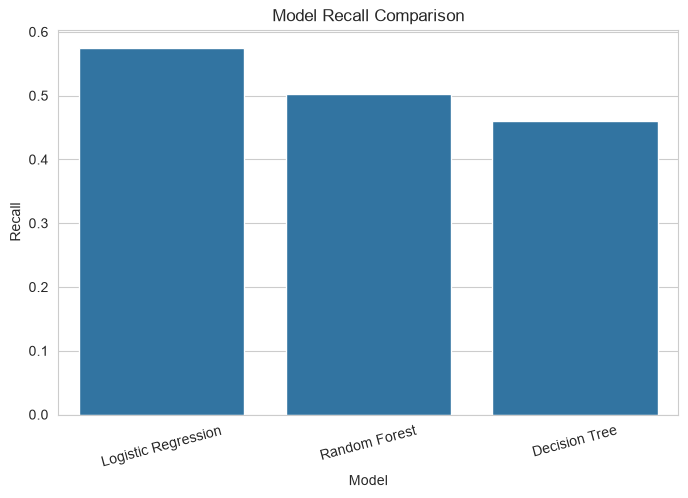

In [28]:
# Cell 28 — Recall Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="Recall"
)

plt.title("Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=15)

plt.show()

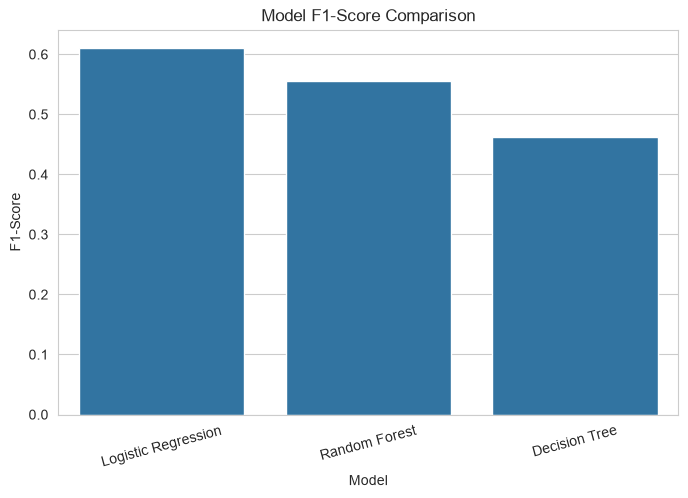

In [29]:
# Cell 29 — F1-Score Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=baseline_results,
    x="Model",
    y="F1-Score"
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=15)

plt.show()

In [30]:
# Cell 30 — Explain Classification Metrics

print("Classification Metrics Explanation")
print("--------------------------------------")

print("""
Accuracy:
Percentage of all predictions that are correct.

Precision:
Among customers predicted as churners, how many actually churned.

Recall:
Among customers who actually churned, how many were correctly identified.

F1-Score:
Harmonic mean of precision and recall.

For churn prediction, accuracy alone can be misleading because
the dataset contains both churned and non-churned customers.
Recall is especially important when the business wants to identify
as many potential churners as possible.
F1-score provides a balance between precision and recall.
""")

Classification Metrics Explanation
--------------------------------------

Accuracy:
Percentage of all predictions that are correct.

Precision:
Among customers predicted as churners, how many actually churned.

Recall:
Among customers who actually churned, how many were correctly identified.

F1-Score:
Harmonic mean of precision and recall.

For churn prediction, accuracy alone can be misleading because
the dataset contains both churned and non-churned customers.
Recall is especially important when the business wants to identify
as many potential churners as possible.
F1-score provides a balance between precision and recall.



In [31]:
# Cell 31 — Transform Training Data for Feature Selection

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)
print("Number of processed features:", len(feature_names))

Processed training shape: (5625, 30)
Processed testing shape: (1407, 30)
Number of processed features: 30


In [32]:
# Cell 32 — Feature Selection Using SelectKBest

k_value = min(20, X_train_processed.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k_value
)

X_train_selected = selector.fit_transform(
    X_train_processed,
    y_train
)

X_test_selected = selector.transform(
    X_test_processed
)

selected_feature_names = feature_names[
    selector.get_support()
]

print("Number of selected features:", len(selected_feature_names))

print("\nSelected Features:")
for feature in selected_feature_names:
    print(feature)

Number of selected features: 20

Selected Features:
num__SeniorCitizen
num__tenure
num__MonthlyCharges
num__TotalCharges
cat__Partner_Yes
cat__Dependents_Yes
cat__InternetService_Fiber optic
cat__InternetService_No
cat__OnlineSecurity_No internet service
cat__OnlineSecurity_Yes
cat__OnlineBackup_No internet service
cat__DeviceProtection_No internet service
cat__TechSupport_No internet service
cat__TechSupport_Yes
cat__StreamingTV_No internet service
cat__StreamingMovies_No internet service
cat__Contract_One year
cat__Contract_Two year
cat__PaperlessBilling_Yes
cat__PaymentMethod_Electronic check


In [33]:
# Cell 33 — Feature Selection Scores

feature_scores = pd.DataFrame({
    "Feature": feature_names,
    "Score": selector.scores_,
    "Selected": selector.get_support()
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

feature_scores.head(20)

,Feature,Score,Selected
1,num__tenure,793.753490,True
10,cat__InternetService_Fiber optic,582.655256,True
28,cat__PaymentMethod_Electronic check,578.158313,True
25,cat__Contract_Two year,563.489866,True
11,cat__InternetService_No,306.683120,True
12,cat__OnlineSecurity_No internet service,306.683120,True
16,cat__DeviceProtection_No internet service,306.683120,True
18,cat__TechSupport_No internet service,306.683120,True
22,cat__StreamingMovies_No internet service,306.683120,True
20,cat__StreamingTV_No internet service,306.683120,True


In [34]:
# Cell 34 — Logistic Regression with Selected Features

selected_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

selected_logistic_model.fit(
    X_train_selected,
    y_train
)

selected_logistic_predictions = (
    selected_logistic_model.predict(X_test_selected)
)

selected_accuracy = accuracy_score(
    y_test,
    selected_logistic_predictions
)

selected_precision = precision_score(
    y_test,
    selected_logistic_predictions
)

selected_recall = recall_score(
    y_test,
    selected_logistic_predictions
)

selected_f1 = f1_score(
    y_test,
    selected_logistic_predictions
)

print("Feature-Selected Logistic Regression")
print("--------------------------------------")
print("Accuracy :", round(selected_accuracy, 4))
print("Precision:", round(selected_precision, 4))
print("Recall   :", round(selected_recall, 4))
print("F1-Score :", round(selected_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    selected_logistic_predictions
))

Feature-Selected Logistic Regression
--------------------------------------
Accuracy : 0.801
Precision: 0.6469
Recall   : 0.5535
F1-Score : 0.5965

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



In [35]:
# Cell 35 — Decision Tree Hyperparameter Tuning

tree_parameter_grid = {
    "preprocessor": [preprocessor],
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

tree_grid_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

tree_grid_search.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(tree_grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(tree_grid_search.best_score_, 4))

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Decision Tree Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unkn

In [36]:
# Cell 36 — Evaluate Tuned Decision Tree

tuned_tree_model = tree_grid_search.best_estimator_

tuned_tree_predictions = tuned_tree_model.predict(X_test)

tuned_tree_accuracy = accuracy_score(
    y_test,
    tuned_tree_predictions
)

tuned_tree_precision = precision_score(
    y_test,
    tuned_tree_predictions
)

tuned_tree_recall = recall_score(
    y_test,
    tuned_tree_predictions
)

tuned_tree_f1 = f1_score(
    y_test,
    tuned_tree_predictions
)

print("Tuned Decision Tree Results")
print("--------------------------------")
print("Accuracy :", round(tuned_tree_accuracy, 4))
print("Precision:", round(tuned_tree_precision, 4))
print("Recall   :", round(tuned_tree_recall, 4))
print("F1-Score :", round(tuned_tree_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_tree_predictions
))

Tuned Decision Tree Results
--------------------------------
Accuracy : 0.7783
Precision: 0.5807
Recall   : 0.5963
F1-Score : 0.5884

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [37]:
# Cell 37 — Random Forest Hyperparameter Tuning

forest_parameter_grid = {
    "preprocessor": [preprocessor],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

forest_grid_search = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=forest_parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

forest_grid_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(forest_grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(forest_grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100, 'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                               

In [38]:
# Cell 38 — Evaluate Tuned Random Forest

tuned_forest_model = forest_grid_search.best_estimator_

tuned_forest_predictions = tuned_forest_model.predict(X_test)

tuned_forest_accuracy = accuracy_score(
    y_test,
    tuned_forest_predictions
)

tuned_forest_precision = precision_score(
    y_test,
    tuned_forest_predictions
)

tuned_forest_recall = recall_score(
    y_test,
    tuned_forest_predictions
)

tuned_forest_f1 = f1_score(
    y_test,
    tuned_forest_predictions
)

print("Tuned Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(tuned_forest_accuracy, 4))
print("Precision:", round(tuned_forest_precision, 4))
print("Recall   :", round(tuned_forest_recall, 4))
print("F1-Score :", round(tuned_forest_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    tuned_forest_predictions
))

Tuned Random Forest Results
--------------------------------
Accuracy : 0.7903
Precision: 0.6321
Recall   : 0.5053
F1-Score : 0.5617

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [39]:
# Cell 39 — Final Model Comparison

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Feature-Selected Logistic Regression",
        "Tuned Decision Tree",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy,
        selected_accuracy,
        tuned_tree_accuracy,
        tuned_forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        forest_precision,
        selected_precision,
        tuned_tree_precision,
        tuned_forest_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        forest_recall,
        selected_recall,
        tuned_tree_recall,
        tuned_forest_recall
    ],
    "F1-Score": [
        logistic_f1,
        tree_f1,
        forest_f1,
        selected_f1,
        tuned_tree_f1,
        tuned_forest_f1
    ]
})

final_results = final_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8053,0.6515,0.5749,0.6108
1,Feature-Selected Logistic Regression,0.8010,0.6469,0.5535,0.5965
2,Tuned Decision Tree,0.7783,0.5807,0.5963,0.5884
3,Tuned Random Forest,0.7903,0.6321,0.5053,0.5617
4,Random Forest,0.7868,0.6225,0.5027,0.5562
5,Decision Tree,0.7164,0.4661,0.4599,0.4630


In [40]:
# Cell 40 — Select Best Model

best_model_name = final_results.loc[0, "Model"]
best_f1_score = final_results.loc[0, "F1-Score"]
best_recall_score = final_results.loc[0, "Recall"]

print("Best Model Based on F1-Score:")
print(best_model_name)

print("\nBest F1-Score:", round(best_f1_score, 4))
print("Recall:", round(best_recall_score, 4))

print("""
The model is selected primarily using F1-score because churn
prediction requires a balance between identifying churners and
avoiding too many incorrect churn predictions.

Recall is also considered because missing an actual churner can
result in a lost opportunity for customer retention.
""")

Best Model Based on F1-Score:
Logistic Regression

Best F1-Score: 0.6108
Recall: 0.5749

The model is selected primarily using F1-score because churn
prediction requires a balance between identifying churners and
avoiding too many incorrect churn predictions.

Recall is also considered because missing an actual churner can
result in a lost opportunity for customer retention.



In [41]:
# Cell 41 — Get Best Model Predictions

best_predictions_dictionary = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "Feature-Selected Logistic Regression": selected_logistic_predictions,
    "Tuned Decision Tree": tuned_tree_predictions,
    "Tuned Random Forest": tuned_forest_predictions
}

best_predictions = best_predictions_dictionary[best_model_name]

print("Best model predictions generated.")
print("Number of predictions:", len(best_predictions))

Best model predictions generated.
Number of predictions: 1407


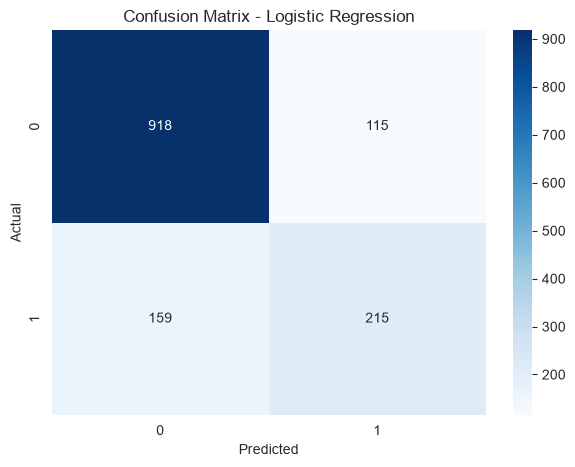

In [42]:
# Cell 42 — Confusion Matrix for Best Model

best_confusion_matrix = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    best_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
# Cell 43 — Classification Report for Best Model

print(f"Classification Report - {best_model_name}")
print("=" * 60)

print(
    classification_report(
        y_test,
        best_predictions
    )
)

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



Best Model: Logistic Regression
ROC-AUC Score: 0.8361


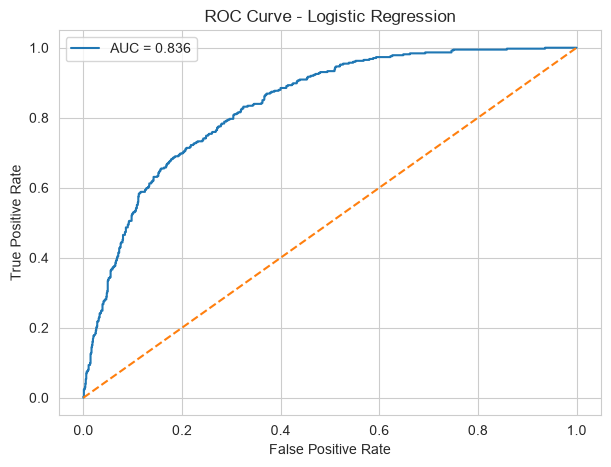

In [44]:
# Cell 44 — ROC-AUC Score and ROC Curve

best_model_objects = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Tuned Decision Tree": tuned_tree_model,
    "Tuned Random Forest": tuned_forest_model
}

if best_model_name in best_model_objects:
    
    best_model = best_model_objects[best_model_name]
    
    best_probabilities = best_model.predict_proba(X_test)[:, 1]
    
else:
    best_probabilities = selected_logistic_model.predict_proba(
        X_test_selected
    )[:, 1]

roc_auc = roc_auc_score(
    y_test,
    best_probabilities
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_probabilities
)

print("Best Model:", best_model_name)
print("ROC-AUC Score:", round(roc_auc, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

In [45]:
# Cell 45 — Feature Importance for Tree-Based Model

if best_model_name in [
    "Random Forest",
    "Tuned Random Forest",
    "Decision Tree",
    "Tuned Decision Tree"
]:

    if "Random Forest" in best_model_name:
        tree_model = best_model.named_steps["model"]
        tree_preprocessor = best_model.named_steps["preprocessor"]
    else:
        tree_model = tuned_tree_model.named_steps["model"]
        tree_preprocessor = tuned_tree_model.named_steps["preprocessor"]

    transformed_feature_names = (
        tree_preprocessor.get_feature_names_out()
    )

    importance_df = pd.DataFrame({
        "Feature": transformed_feature_names,
        "Importance": tree_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    print("Top 15 Important Features:")
    display(importance_df.head(15))

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=importance_df.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

else:
    print("The selected model is Logistic Regression.")
    print("Logistic Regression coefficients will be analyzed instead.")

The selected model is Logistic Regression.
Logistic Regression coefficients will be analyzed instead.


In [46]:
# Cell 46 — Logistic Regression Coefficients

if "Logistic Regression" in best_model_name:

    if best_model_name == "Feature-Selected Logistic Regression":
        
        coefficient_values = selected_logistic_model.coef_[0]
        coefficient_features = selected_feature_names
        
    else:
        
        logistic_preprocessor = logistic_model.named_steps[
            "preprocessor"
        ]
        
        logistic_estimator = logistic_model.named_steps[
            "model"
        ]
        
        coefficient_features = (
            logistic_preprocessor.get_feature_names_out()
        )
        
        coefficient_values = logistic_estimator.coef_[0]

    coefficients_df = pd.DataFrame({
        "Feature": coefficient_features,
        "Coefficient": coefficient_values
    })

    coefficients_df["Absolute_Coefficient"] = (
        coefficients_df["Coefficient"].abs()
    )

    coefficients_df = coefficients_df.sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )

    print("Most Influential Logistic Regression Features:")
    display(coefficients_df.head(15))

else:
    print("The selected model is tree-based.")
    print("Feature importance was analyzed in the previous cell.")

Most Influential Logistic Regression Features:


,Feature,Coefficient,Absolute_Coefficient
25,cat__Contract_Two year,-1.364823,1.364823
1,num__tenure,-1.357404,1.357404
10,cat__InternetService_Fiber optic,1.107407,1.107407
24,cat__Contract_One year,-0.750068,0.750068
3,num__TotalCharges,0.645508,0.645508
7,cat__PhoneService_Yes,-0.515337,0.515337
2,num__MonthlyCharges,-0.434497,0.434497
28,cat__PaymentMethod_Electronic check,0.379150,0.379150
13,cat__OnlineSecurity_Yes,-0.373187,0.373187
21,cat__StreamingTV_Yes,0.372407,0.372407


In [47]:
# Cell 47 — Create Test Prediction Table

test_results = X_test.copy()

test_results["Actual_Churn"] = y_test.values
test_results["Predicted_Churn"] = best_predictions
test_results["Churn_Probability"] = best_probabilities

test_results.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Churn,Churn_Probability
974,Female,0,Yes,Yes,59,Yes,No,DSL,No,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),75.95,4542.35,0,0,0.018022
619,Female,0,No,No,7,Yes,Yes,Fiber optic,No,Yes,...,No,No,Month-to-month,Yes,Bank transfer (automatic),78.55,522.95,0,1,0.591832
4289,Female,0,No,No,54,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Mailed check,20.10,1079.45,0,0,0.004892
3721,Female,0,No,No,2,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Mailed check,20.65,38.70,1,0,0.201424
4533,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.15,7555.00,0,0,0.103762
445,Female,0,No,No,60,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,6396.45,1,0,0.470521
5898,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,One year,No,Credit card (automatic),24.15,800.30,0,0,0.026390
3387,Female,0,No,No,7,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,No,Mailed check,20.65,155.90,0,0,0.165104
1346,Female,0,Yes,Yes,14,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,87.25,1258.60,1,1,0.676429
5690,Male,0,No,No,72,No,No phone service,DSL,Yes,No,...,Yes,Yes,Two year,Yes,Credit card (automatic),61.20,4390.25,0,0,0.015717


In [48]:
# Cell 48 — Identify Customers Predicted as Churners

predicted_churners = test_results[
    test_results["Predicted_Churn"] == 1
].copy()

print(
    "Customers predicted as churners:",
    predicted_churners.shape[0]
)

predicted_churners.head(10)

Customers predicted as churners: 330


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Churn,Churn_Probability
619,Female,0,No,No,7,Yes,Yes,Fiber optic,No,Yes,...,No,No,Month-to-month,Yes,Bank transfer (automatic),78.55,522.95,0,1,0.591832
1346,Female,0,Yes,Yes,14,Yes,Yes,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,87.25,1258.60,1,1,0.676429
4283,Male,1,Yes,No,4,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.20,280.35,0,1,0.707121
6128,Female,0,Yes,No,14,Yes,No,Fiber optic,No,No,...,No,Yes,Month-to-month,Yes,Electronic check,78.10,1122.40,0,1,0.651572
346,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,90.40,168.20,1,1,0.775396
6718,Male,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,No,Mailed check,75.00,209.10,1,1,0.608698
2039,Male,0,No,No,22,Yes,Yes,Fiber optic,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,79.35,1730.35,1,1,0.556729
3682,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,69.10,69.10,1,1,0.696884
139,Female,1,Yes,No,1,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Mailed check,70.45,70.45,1,1,0.668600
2968,Male,0,No,No,3,Yes,No,Fiber optic,No,Yes,...,No,Yes,Month-to-month,No,Electronic check,90.40,268.45,0,1,0.615347


In [49]:
# Cell 49 — Business Interpretation of Model Results

print("Business Interpretation")
print("=" * 60)

print(
    f"""
The selected model is: {best_model_name}

The model achieved an F1-score of {best_f1_score:.4f}
and a recall of {best_recall_score:.4f} on the test dataset.

The model can help the business identify customers who have
characteristics associated with churn based on the available
customer information.

Predictions should be treated as model-based classifications or
probabilities rather than certainty that a customer will churn.

The model can support retention teams by helping prioritize
customers for further investigation and proactive engagement.
"""
)

Business Interpretation

The selected model is: Logistic Regression

The model achieved an F1-score of 0.6108
and a recall of 0.5749 on the test dataset.

The model can help the business identify customers who have
characteristics associated with churn based on the available
customer information.

Predictions should be treated as model-based classifications or
probabilities rather than certainty that a customer will churn.

The model can support retention teams by helping prioritize
customers for further investigation and proactive engagement.



In [50]:
# Cell 50 — Business Recommendations

print("Business Recommendations")
print("=" * 60)

print("""
1. Prioritize customers predicted to have a higher probability
   of churn for proactive retention campaigns.

2. Investigate the important features identified by the final
   model to understand the main factors associated with churn.

3. Consider personalized offers or service improvements for
   customers showing high churn probability.

4. Monitor month-to-month customers carefully if the model and
   dataset indicate that this group has elevated churn risk.

5. Pay attention to high-value customers with high predicted
   churn probability because their retention can have greater
   revenue importance.

6. Use model predictions as a decision-support tool rather than
   treating them as guaranteed future outcomes.

7. Periodically retrain and evaluate the model when new customer
   data becomes available.
""")

Business Recommendations

1. Prioritize customers predicted to have a higher probability
   of churn for proactive retention campaigns.

2. Investigate the important features identified by the final
   model to understand the main factors associated with churn.

3. Consider personalized offers or service improvements for
   customers showing high churn probability.

4. Monitor month-to-month customers carefully if the model and
   dataset indicate that this group has elevated churn risk.

5. Pay attention to high-value customers with high predicted
   churn probability because their retention can have greater
   revenue importance.

6. Use model predictions as a decision-support tool rather than
   treating them as guaranteed future outcomes.

7. Periodically retrain and evaluate the model when new customer
   data becomes available.



In [51]:
# Cell 51 — Final Summary

total_customers = len(df)
actual_churn_rate = df["Churn"].mean() * 100

print("Task 4 — Churn Prediction Model")
print("=" * 60)

print("Total Customers:", total_customers)
print("Overall Churn Rate:", round(actual_churn_rate, 2), "%")
print("Training Customers:", len(X_train))
print("Testing Customers:", len(X_test))

print("\nBest Model:", best_model_name)
print("Accuracy:", round(
    final_results.loc[
        final_results["Model"] == best_model_name,
        "Accuracy"
    ].iloc[0], 4
))

print("Precision:", round(
    final_results.loc[
        final_results["Model"] == best_model_name,
        "Precision"
    ].iloc[0], 4
))

print("Recall:", round(
    final_results.loc[
        final_results["Model"] == best_model_name,
        "Recall"
    ].iloc[0], 4
))

print("F1-Score:", round(
    final_results.loc[
        final_results["Model"] == best_model_name,
        "F1-Score"
    ].iloc[0], 4
))

print("ROC-AUC:", round(roc_auc, 4))

print("""
Conclusion:
Multiple classification algorithms were trained and evaluated.
Feature selection and hyperparameter tuning were also performed.
The final model was selected using F1-score while considering
recall because identifying potential churners is important for
customer retention.
""")

Task 4 — Churn Prediction Model
Total Customers: 7032
Overall Churn Rate: 26.58 %
Training Customers: 5625
Testing Customers: 1407

Best Model: Logistic Regression
Accuracy: 0.8053
Precision: 0.6515
Recall: 0.5749
F1-Score: 0.6108
ROC-AUC: 0.8361

Conclusion:
Multiple classification algorithms were trained and evaluated.
Feature selection and hyperparameter tuning were also performed.
The final model was selected using F1-score while considering
recall because identifying potential churners is important for
customer retention.



In [52]:
# Cell 52 — Save Model Comparison Results

final_results.to_csv(
    "churn_model_comparison.csv",
    index=False
)

print("Model comparison saved as:")
print("churn_model_comparison.csv")

Model comparison saved as:
churn_model_comparison.csv


In [53]:
# Cell 53 — Save Customer Predictions

prediction_output = test_results.copy()

prediction_output.to_csv(
    "churn_customer_predictions.csv",
    index=False
)

print("Customer predictions saved as:")
print("churn_customer_predictions.csv")

Customer predictions saved as:
churn_customer_predictions.csv


In [54]:
# Cell 54 — Save Feature Importance or Coefficients

if "importance_df" in globals():

    importance_df.to_csv(
        "churn_feature_importance.csv",
        index=False
    )

    print("Feature importance saved as:")
    print("churn_feature_importance.csv")

elif "coefficients_df" in globals():

    coefficients_df.to_csv(
        "churn_logistic_coefficients.csv",
        index=False
    )

    print("Logistic regression coefficients saved as:")
    print("churn_logistic_coefficients.csv")

else:
    print("No feature importance or coefficient table available.")

Logistic regression coefficients saved as:
churn_logistic_coefficients.csv


In [55]:
# Cell 55 — Final Project Completion Message

print("=" * 70)
print("TASK 4 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("""
Churn Prediction Model workflow completed:

✓ Dataset loading and inspection
✓ Data cleaning
✓ Churn target preparation
✓ Train-test split
✓ Numerical and categorical preprocessing
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ Accuracy, Precision, Recall and F1-score
✓ Classification reports
✓ Confusion matrices
✓ Feature selection
✓ Hyperparameter tuning
✓ Cross-validation
✓ Final model comparison
✓ Best model selection
✓ ROC-AUC and ROC curve
✓ Feature importance / coefficients
✓ Customer churn predictions
✓ Business interpretation
✓ Business recommendations
✓ Results exported to CSV files
""")

TASK 4 COMPLETED SUCCESSFULLY

Churn Prediction Model workflow completed:

✓ Dataset loading and inspection
✓ Data cleaning
✓ Churn target preparation
✓ Train-test split
✓ Numerical and categorical preprocessing
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ Accuracy, Precision, Recall and F1-score
✓ Classification reports
✓ Confusion matrices
✓ Feature selection
✓ Hyperparameter tuning
✓ Cross-validation
✓ Final model comparison
✓ Best model selection
✓ ROC-AUC and ROC curve
✓ Feature importance / coefficients
✓ Customer churn predictions
✓ Business interpretation
✓ Business recommendations
✓ Results exported to CSV files

